In [3]:
import pickle
from torch.utils.data import Subset
from torch_geometric.datasets import BA2MotifDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv,global_add_pool
from torch_geometric.loader import DataLoader
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import random_split
import matplotlib.pyplot as plt

from utils.data import load_data
from utils.models import GINGraphClf,train_one_epoch,evaluate,test_evaluation




In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## loading data and split

In [3]:
dataset=load_data("./data/BA2Motif")
with open("./data/splits.pkl", "rb") as f:
    splits=pickle.load(f)

train_dataset=Subset(dataset,splits["train"])
val_dataset=Subset(dataset,splits["val"])
test_dataset=Subset(dataset,splits["test"])


In [4]:

config={
    'hidden_dim':64,
    'learning_rate':0.001,
    'weight_decay':0.001,
    'epochs':100,
    'batch_size':32,
    'patience':10           # early stopping
}



In [5]:
train_loader=DataLoader(train_dataset,batch_size=config['batch_size'],shuffle=True)
validation_loader=DataLoader(val_dataset,batch_size=config['batch_size'],shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=config['batch_size'],shuffle=False)

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Training

In [7]:
model=GINGraphClf(dataset.num_node_features,dataset.num_classes).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=config['learning_rate'],weight_decay=config['weight_decay'])
criterion=nn.CrossEntropyLoss()

In [8]:
best_val_acc=0.0
patience_counter=0
best_model_state=None

train_losses = []
val_accs = []


with tqdm(total=config["epochs"],desc="Training epochs",unit="epoch") as pbar_epoch:
    for epoch in range(config["epochs"]):
        train_loss=train_one_epoch(model,train_loader,optimizer,criterion,device)
        val_acc=evaluate(model,validation_loader,device)
        train_losses.append(train_loss)
        val_accs.append(val_acc)
        pbar_epoch.set_postfix({"train_loss":train_loss,"val_acc":val_acc})
        pbar_epoch.update(1)
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            patience_counter=0
            best_model_state=model.state_dict().copy()
        else:
            patience_counter+=1
            if patience_counter>=config["patience"]:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                break

model.load_state_dict(best_model_state)
tqdm.write(f"Best validation accuracy: {best_val_acc:.4f}")

Training epochs:  18%|█▊        | 18/100 [00:04<00:19,  4.17epoch/s, train_loss=0.315, val_acc=1]   

Early stopping at epoch 18
Best validation accuracy: 1.0000


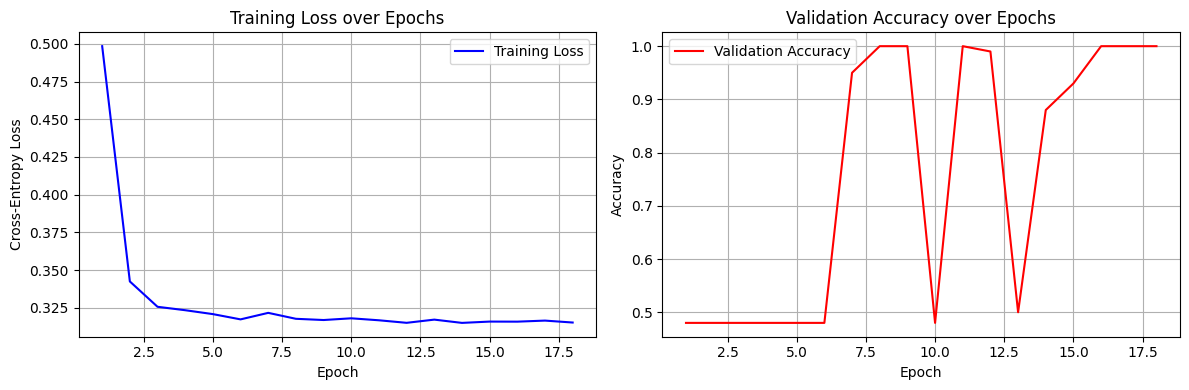

In [9]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
model.eval()
for param in model.parameters():
    param.requires_grad=False

torch.save({
    'model_state_dict':best_model_state,
    'config':config,
    'best_val_acc':best_val_acc,
},"./models/GIN/best_gin_model.pt"
)
tqdm.write(" Model frozen and saved as 'best_gin_model.pt'")

 Model frozen and saved as 'best_gin_model.pt'


## Evaluating

In [11]:
model=GINGraphClf(test_dataset[0].num_features,2).to(device)

checkpoint=torch.load('./models/GIN/best_gin_model.pt',map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()
for param in model.parameters():
    param.requires_grad = False


In [12]:
test_acc ,correct_indices,wrong_indices= test_evaluation(model, test_loader, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Number of correct predictions: {len(correct_indices)}")

Test Accuracy: 1.0000
Number of correct predictions: 100


In [13]:
test_result_split={
    "correct": correct_indices,
    "wrong": wrong_indices
}
with open('./data/test_result.pkl','wb') as f:
    pickle.dump(test_result_split,f)

print("data indices saved to ./data/test_result.pkl")

data indices saved to ./data/test_result.pkl


# Explanation

### Baseline

In [14]:
from utils.graph_function import baseline_explanation,subgraph_explanation
from utils.visualization import visualize_explanation

In [15]:
fidelity_dorp_score=0
for key in test_result_split.keys():
    if len(test_result_split[key]) == 0:
        continue
    max_pic=10
    if len(test_result_split[key])<max_pic:
        max_pic=len(test_result_split[key])
        random_indices=list(range(0, len(test_result_split[key])))
    
    else:
        random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()

    for i in range(len(test_result_split[key])):
        data=test_dataset[test_result_split[key][i]['index']]
        pred_class=test_result_split[key][i]['pred']
        explanation_graph, selected_nodes,fidelity_score = baseline_explanation(
            model, data, target_class=pred_class, budget=0.2, device=device
        )
        fidelity_dorp_score+=fidelity_score
        if i in random_indices:
            visualize_explanation(data.cpu(), selected_nodes,save_path=f"./explanation/baseline/{key}/index_{test_result_split[key][i]['index']}.png")  

print(f" fidelity score: {fidelity_dorp_score/len(test_dataset)}")


 fidelity score: 0.4399130000000002


### Subgraph Explanation

In [16]:
fidelity_dorp_score=0
for key in test_result_split.keys():
    if len(test_result_split[key]) == 0:
        continue
    max_pic=10
    if len(test_result_split[key])<max_pic:
        max_pic=len(test_result_split[key])
        random_indices=list(range(0, len(test_result_split[key])))
    
    else:
        random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()
    
    random_indices=torch.randint(0,len(test_result_split[key])-1,(max_pic,)).tolist()
    for i in range(len(test_result_split[key])):
        data=test_dataset[test_result_split[key][i]['index']]
        pred_class=test_result_split[key][i]['pred']
        explanation_graph, removed_nodes,fidelity_score = subgraph_explanation(
            model, data, target_class=pred_class, budget=0.2, device=device
        )
        fidelity_dorp_score+=fidelity_score
        if i in random_indices:
            all_nodes = set(range(data.num_nodes))
            remaining_nodes = list(all_nodes - set(removed_nodes))
            visualize_explanation(data.cpu(), remaining_nodes,save_path=f"./explanation/subgraph_explanation/{key}/index_{test_result_split[key][i]['index']}.png")  

print(f" fidelity score: {fidelity_dorp_score/len(test_dataset)}")


 fidelity score: 0.04337329789996147
